In [ ]:
from pathlib import Path
import sys


here = Path.cwd()
candidates = [here] + list(here.parents)
for p in candidates:
    if (p / "Code").is_dir():
        sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Couldn't find a 'Code' folder in this project.")

import autograd.numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Code.ffnn2 import NeuralNetwork as FFNN 
from Code.scheduler import Adam, RMS_prop, Constant, Scheduler
from Code.activations import sigmoid, identity, derivate 
import pandas as pd
import seaborn as sns 
sns.set_theme(style="white", font_scale=1.3)
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 200
plt.rcParams.update({
    "savefig.dpi": 200,
    "savefig.bbox": "tight"
})


""" sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams.update({
    "figure.figsize": (14,8),
    "figure.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
}) """


' sns.set_theme(style="whitegrid", font_scale=1.3)\nplt.rcParams.update({\n    "figure.figsize": (14,8),\n    "figure.dpi": 200,\n    "axes.titlesize": 14,\n    "axes.labelsize": 12,\n    "xtick.labelsize": 11,\n    "ytick.labelsize": 11,\n    "legend.fontsize": 11\n}) '

In [2]:
"""Data prep"""

def runge_function(x):
    return 1.0 / (1.0 + 25 * x**2) 

N = 100
x = np.linspace(-1, 1, N).reshape(-1, 1)
y = runge_function(x) 

# Scale data 
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42) 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

In [3]:
"""Cost functions"""

def CostOLS(pred, target):
    """Mean squared error over the batch."""
    return np.mean((pred - target) ** 2)

def dCostOLS(pred, target):
    """Derivative of MSE wrt predictions (averaged over batch)."""
    N = pred.shape[0]
    return (2.0 / N) * (pred - target)


In [4]:
"""Helper for running the comparisons etc"""

def run_comparison(optimizer, X_train, t_train, network_input_size, layer_output_sizes, **kwargs):
    # Determine activation functions based on layers count
    n_hidden_layers = len(layer_output_sizes) - 1
    
    # Sigmoid for hidden layers, Identity for output (Regression)
    activation_funcs = [sigmoid] * n_hidden_layers + [identity]
    activation_ders = [derivate(f) for f in activation_funcs] # Derivatives of the activation functions
    
    # Initialize NN 

    nn = FFNN(
    network_input_size=network_input_size, 
    layer_output_sizes=tuple(layer_output_sizes),
    activation_funcs=activation_funcs,  # List/tuple of all activation functions (hidden + output) 
    activation_ders=activation_ders,    # List/tuple of all corresponding derivatives 
    cost_fun=CostOLS,                  # Cost function 
    cost_der=dCostOLS, 
    seed=42
    )

    nn.reset_weights()

    # Extract common nn.fit arguments from kwargs (epochs, batches, lam) 
    epochs = kwargs.pop('epochs', 100)
    batches = kwargs.pop('batches', 25)
    lam = kwargs.pop('lam', 0.0)
    l1  = kwargs.pop('l1', None)          
    l2  = kwargs.pop('l2', None) 

    # Instantiate the scheduler using remaining kwargs (eta, rho, rho2, etc.)
    opt_args = {k: v for k, v in kwargs.items() if k in ("eta", "rho", "rho2", "eps", "beta1", "beta2")}
    scheduler_instance = optimizer(**opt_args)

    # Train the network
    scores = nn.fit(
        X_train, 
        t_train, 
        scheduler=scheduler_instance, 
        epochs=epochs, 
        batches=batches,
        lam=lam,
        l1=l1,
        l2=l2
    )
    return scores, nn


# Part b

In [5]:
"""Parameters for comparisons and sweeps"""
input_nodes = X_train_scaled.shape[1] 
output_nodes = 1
batches_gd = 1
epochs_comparison = 1000 
lam = 0.0
hidden_nodes1 = 50
hidden_nodes2 = 100

# Architecture 1: One Hidden Layer (50 nodes) 
layer_sizes_1H = [hidden_nodes1, output_nodes]

# Architecture 2: Two Hidden Layers (50 and 100 nodes)
layer_sizes_2H = [hidden_nodes1, hidden_nodes2, output_nodes]

eta_base = 0.01 
rho_val = 0.9      # Recommended rho for RMSprop/Adam 
rho2_val = 0.999   # Recommended rho2 for Adam 

# Optimizers to sweep
optimizers_to_sweep = {
    'GD': (Constant, {'batches': batches_gd}),
    'SGD': (Constant, {}),
    'RMS_prop': (RMS_prop, {'rho': rho_val}),
    'Adam': (Adam, {'rho': rho_val, 'rho2': rho2_val})
}
eta_vals = np.logspace(-5, -1, 5) # Sweep 5 values
epochs_sweep = 500



### Sweep hyperparameters: 

In [6]:
all_sweep_results = {}

# Architectures (layers and nodes) to sweep
architectures_to_sweep = {
    '1_Hidden_Layer (50)': layer_sizes_1H,
    '2_Hidden_Layers (50, 100)': layer_sizes_2H
}


# hyperparameter sweep 
# Iterate over architectures
for arch_name, layer_sizes in architectures_to_sweep.items():
    print(f"\n================ {arch_name} ================")
    arch_scores = {}

    # Iterate over optimizers
    for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
        print(f"--- Optimizer {opt_name} ---")
        mse_scores_for_eta = []
        
        # Iterate over eta values
        for eta in eta_vals:
            # Prepare kwargs for the current run
            current_kwargs = {'eta': eta}
            current_kwargs.update(fixed_params)
            
            # Run comparison using the defined architecture
            scores, nn = run_comparison(
                optimizer_class,
                X_train_scaled, 
                y_train,
                network_input_size=input_nodes,
                layer_output_sizes=layer_sizes,
                epochs=epochs_sweep,  
                lam=lam,
                **current_kwargs
            )
            
            y_pred_test = nn.predict(X_test_scaled) 

            # Get the final mse
            final_mse = CostOLS(y_pred_test, y_test)
            mse_scores_for_eta.append(final_mse)
            print(f"  {opt_name} (eta={eta:.1e}): MSE={final_mse:.6f}")
        
        arch_scores[opt_name] = mse_scores_for_eta

    all_sweep_results[arch_name] = arch_scores


================ 1_Hidden_Layer (50) ================
--- Optimizer GD ---
  GD (eta=1.0e-05): MSE=0.134777
  GD (eta=1.0e-04): MSE=0.071398
  GD (eta=1.0e-03): MSE=0.069229
  GD (eta=1.0e-02): MSE=0.069229
  GD (eta=1.0e-01): MSE=0.069235
--- Optimizer SGD ---
  SGD (eta=1.0e-05): MSE=0.068645


KeyboardInterrupt: 

### Visualization

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/var/folders/yn/p45qg2hs32j6_2k0vv9s4kcw0000gn/T/ipykernel_33267/1175193696.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Learning Rate ($\eta$)')


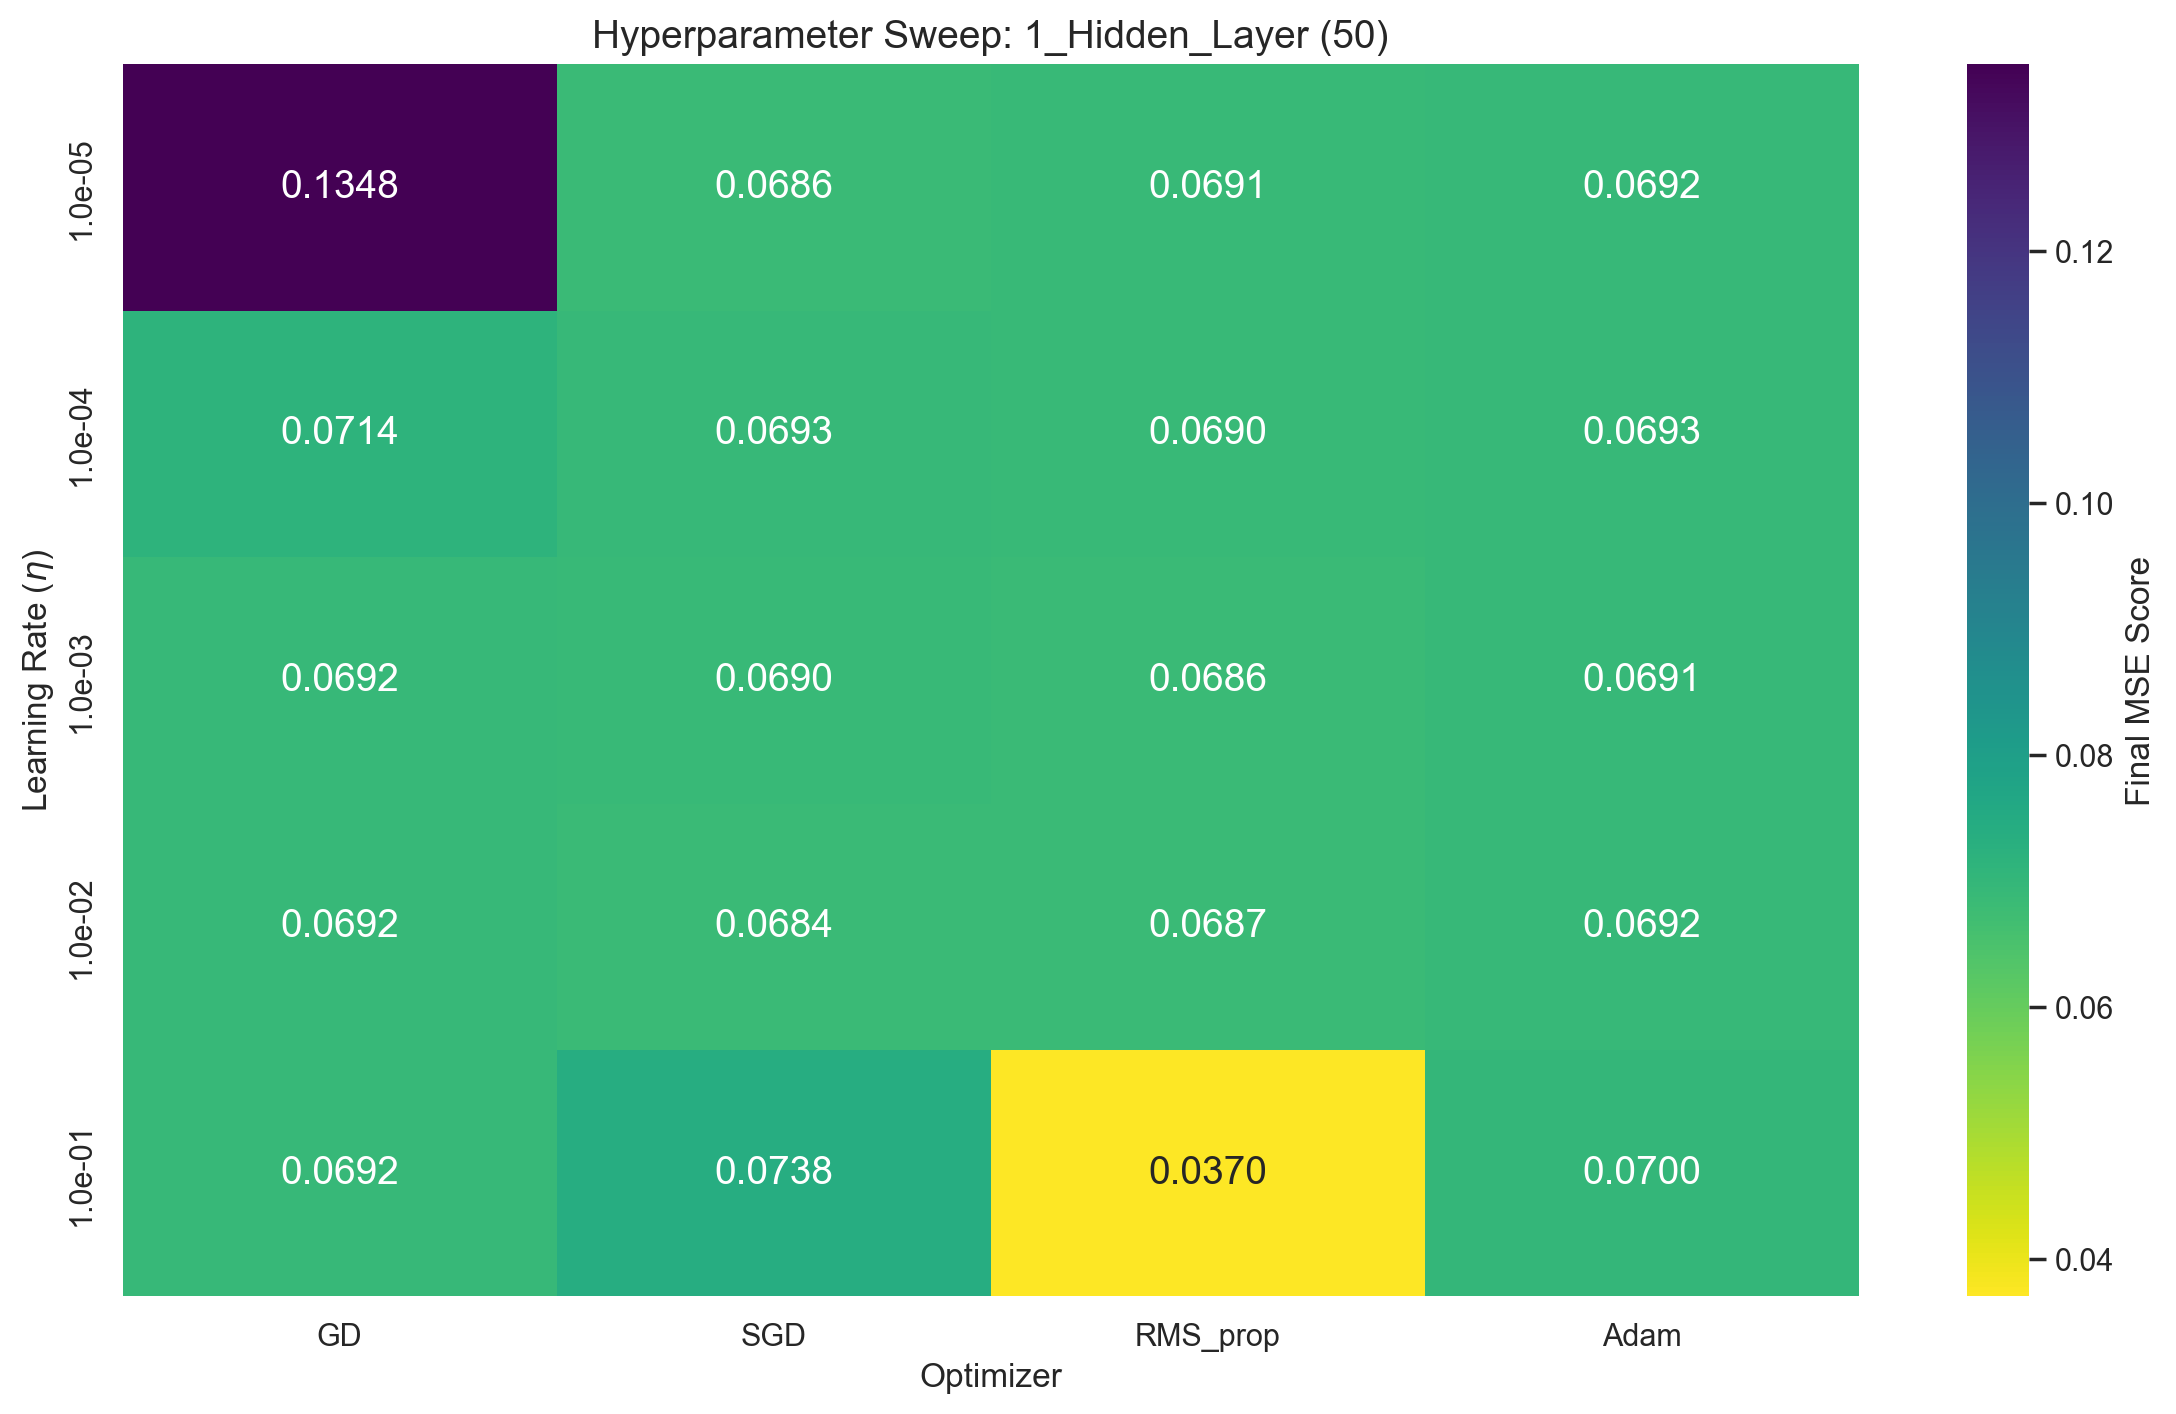

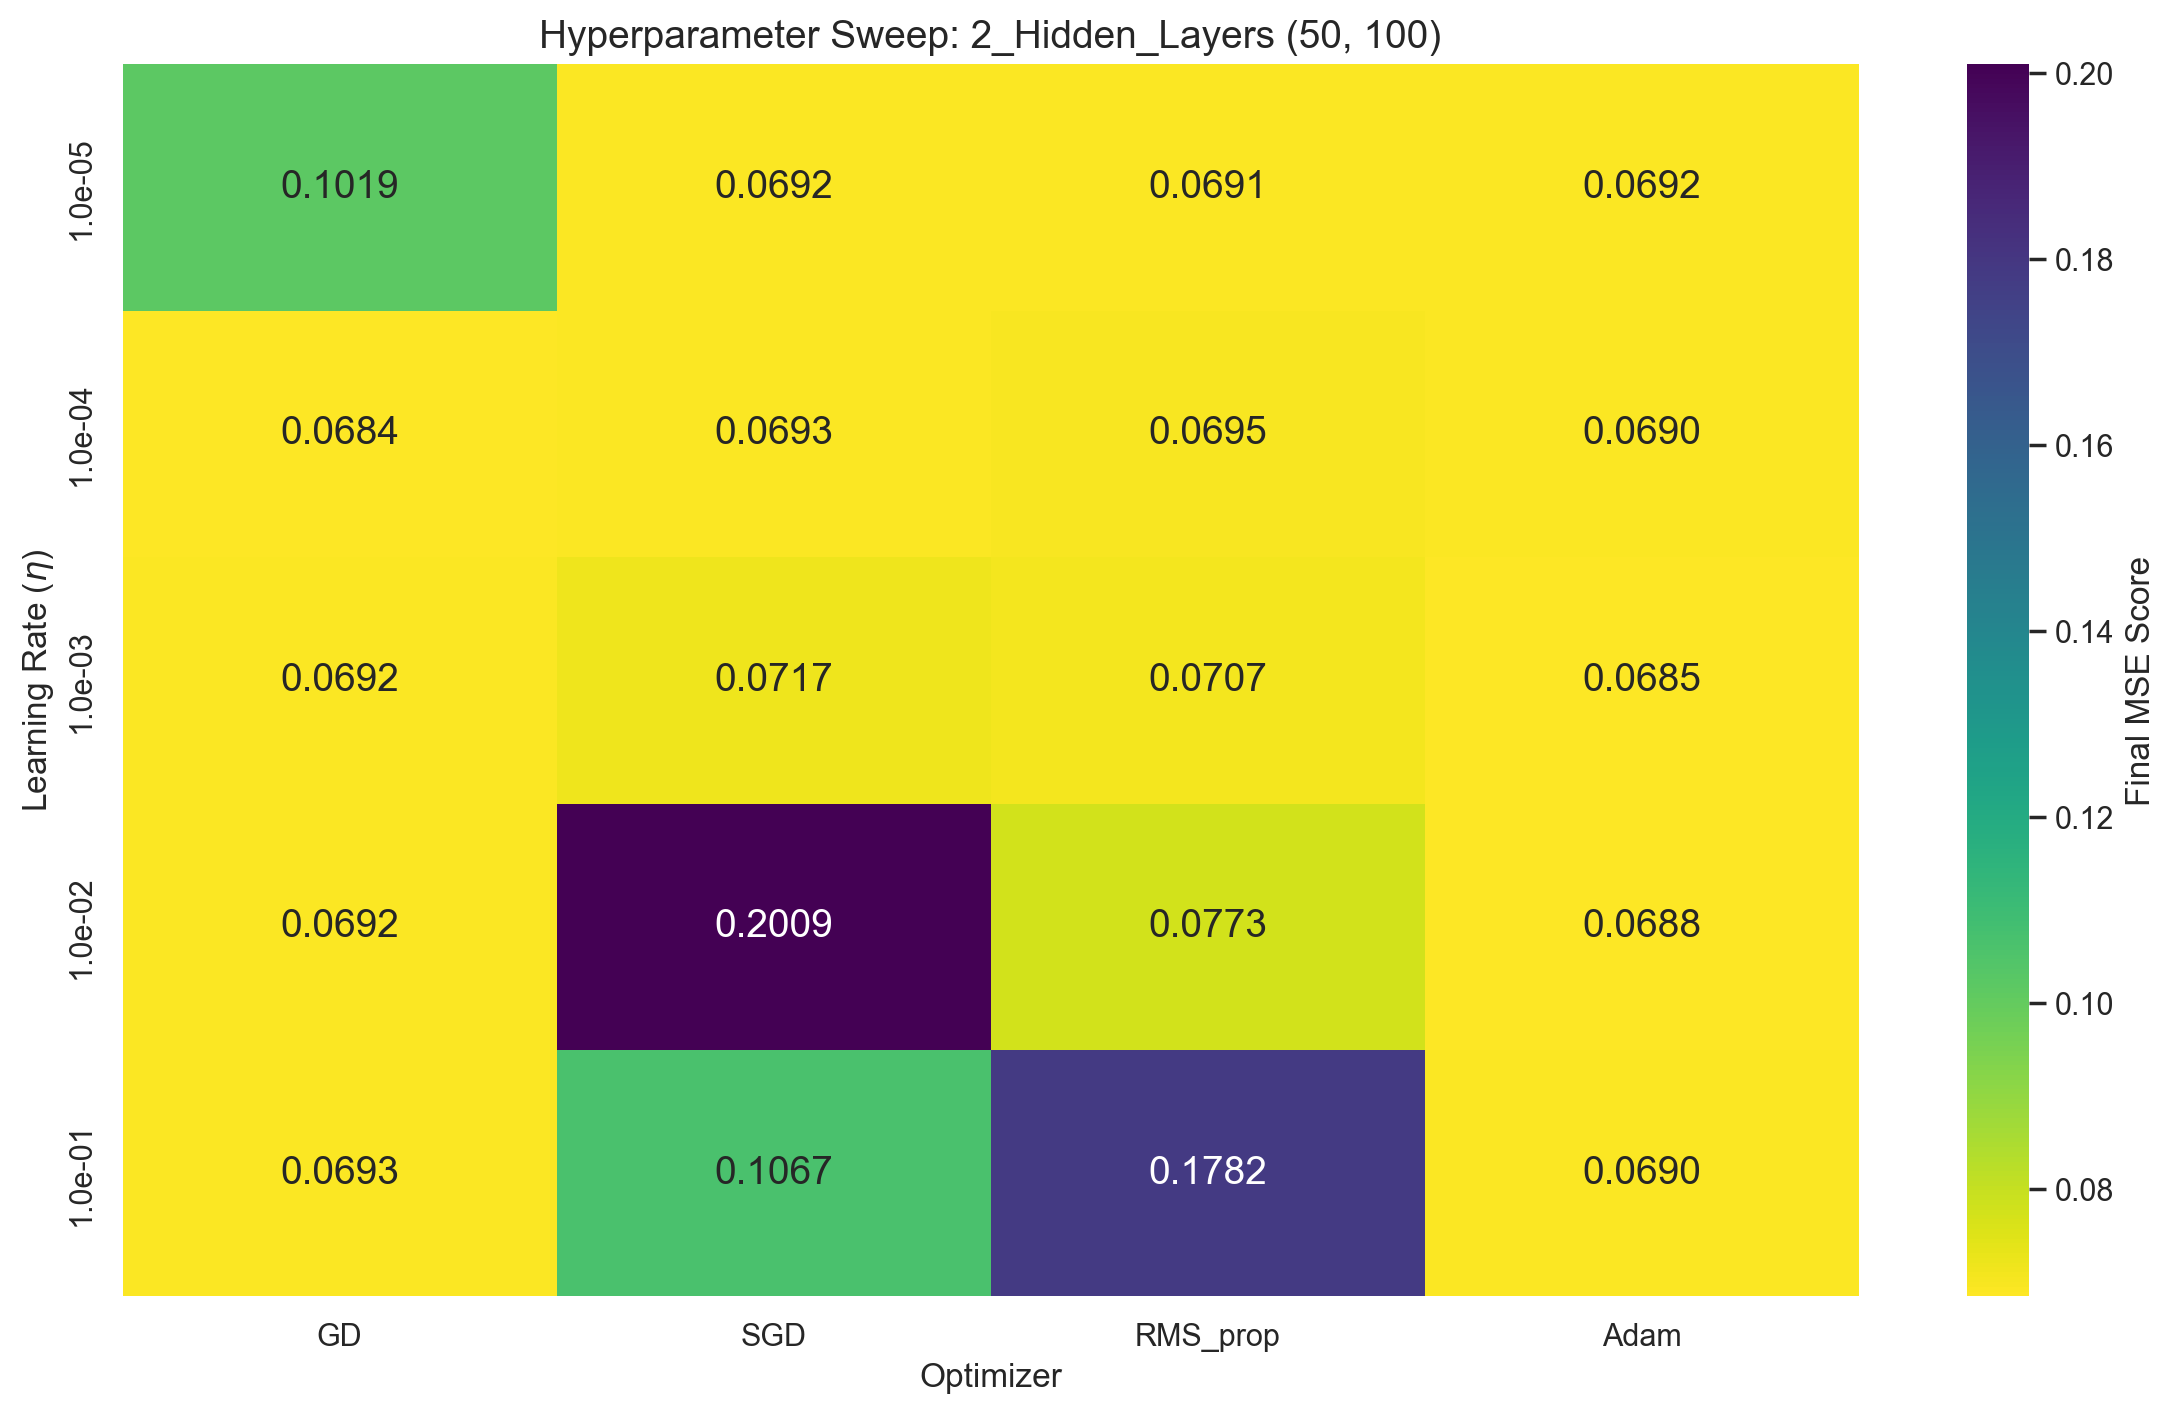

In [ ]:
def plot_sweep_heatmap(sweep_data, eta_vals, title):
    """Heatmap of final MSE scores."""
    
    df = pd.DataFrame(sweep_data, index=[f"{e:.1e}" for e in eta_vals]) # Rows: eta, Columns: Optimizers
    
    plt.figure(figsize=(14, 8), dpi=200)
    sns.heatmap(
        df, 
        annot=True, 
        fmt=".4f", 
        cmap="viridis_r", 
        cbar_kws={'label': 'Final MSE Score'}, 
        annot_kws={"size": 14}
    )
    plt.title(f'Hyperparameter Sweep: {title}')
    plt.ylabel('Learning Rate ($\eta$)')
    plt.xlabel('Optimizer')
    plt.show()

# Generate heatmaps for each layer architecture
for arch_name, sweep_data in all_sweep_results.items():
    plot_sweep_heatmap(sweep_data, eta_vals, arch_name)

# Part c

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

eta_val = 1e-1

mlp_regressor = MLPRegressor(
    # Architecture: Two hidden layers with 50 and 100 nodes
    hidden_layer_sizes=(hidden_nodes1, hidden_nodes2),
    # Hidden Layer Activation: Using sigmoid 
    activation='logistic', # 'logistic' is the string for sigmoid in Scikit-learn
    # L2 Regularization parameter (alpha corresponds to lambda)
    alpha=lam,
    # Optimizer
    solver='sgd',
    # Initial Learning Rate
    learning_rate_init=eta_val,
    # Max Epochs
    max_iter=1000,
    # Seed
    random_state=42
)



In [ ]:
# y_train is raveled to ensure Scikit-Learn compatibility for regression
mlp_regressor.fit(X_train_scaled, y_train.ravel())

# Predict on test set
y_pred_skl = mlp_regressor.predict(X_test_scaled)


skl_optimizers = {
    'SGD': 'sgd',
    'Adam': 'adam'
}


architectures_to_sweep = {
    '1_Hidden_Layer (50)': layer_sizes_1H,
    '2_Hidden_Layers (50, 100)': layer_sizes_2H
}
epochs_skl = 1000 

skl_sweep_results = {}

# Hyperparameter sweep for Scikit-Learn MLPRegressor
# Iterate over architectures
for arch_name, layer_sizes in architectures_to_sweep.items():
    hidden_layer_arch = layer_sizes[:-1]
    arch_scores = {}
    print(f"\n================ Starting SKL Sweep for Architecture: {arch_name} ================")

    # Iterate over optimizers
    for opt_name, solver_type in skl_optimizers.items():
        print(f"--- Running {opt_name} ---")
        mse_scores_for_eta = [] # List to store MSE for each eta value

        # Iterate over eta values
        for eta in eta_vals:
            
            # Initialize MLPRegressor model for the current combination
            skl_model = MLPRegressor(
                
                hidden_layer_sizes=hidden_layer_arch, 
                
                # Configuration matching the custom FFNN regression model:
                activation='logistic',       # Sigmoid activation 
                alpha=lam,                   # L2 regularization (lambda)
                solver=solver_type,          # Optimizer (sgd or adam)
                learning_rate_init=eta,      # Learning rate (eta)
                max_iter=epochs_skl,         # Max epochs
                random_state=42,             # Seed
            )

            # Train the model
            # y_train is raveled to ensure Scikit-Learn compatibility for regression
            skl_model.fit(X_train_scaled, y_train.ravel()) 

            # Predict on test set
            y_pred_skl = skl_model.predict(X_test_scaled)
            final_mse = mean_squared_error(y_test, y_pred_skl)
            mse_scores_for_eta.append(final_mse)

            print(f"  {opt_name} (eta={eta:.1e}): Test MSE={final_mse:.6f}")

        # Store the list of scores for the current optimizer under the current architecture
        arch_scores[opt_name] = mse_scores_for_eta

    # Store all optimizer results for the current architecture
    skl_sweep_results[arch_name] = arch_scores




================ Starting SKL Sweep for Architecture: 1_Hidden_Layer (50) ================
--- Running SGD ---
  SGD (eta=1.0e-05): Test MSE=0.123220
  SGD (eta=1.0e-04): Test MSE=0.070069
  SGD (eta=1.0e-03): Test MSE=0.077351
  SGD (eta=1.0e-02): Test MSE=0.071326
  SGD (eta=1.0e-01): Test MSE=0.223419
--- Running Adam ---
  Adam (eta=1.0e-05): Test MSE=0.169994
  Adam (eta=1.0e-04): Test MSE=0.069834
  Adam (eta=1.0e-03): Test MSE=0.079271
  Adam (eta=1.0e-02): Test MSE=0.068415
  Adam (eta=1.0e-01): Test MSE=0.109731

================ Starting SKL Sweep for Architecture: 2_Hidden_Layers (50, 100) ================
--- Running SGD ---
  SGD (eta=1.0e-05): Test MSE=0.092559
  SGD (eta=1.0e-04): Test MSE=0.068362
  SGD (eta=1.0e-03): Test MSE=0.078063
  SGD (eta=1.0e-02): Test MSE=0.069446
  SGD (eta=1.0e-01): Test MSE=0.068391
--- Running Adam ---
  Adam (eta=1.0e-05): Test MSE=0.081871
  Adam (eta=1.0e-04): Test MSE=0.069822
  Adam (eta=1.0e-03): Test MSE=0.068501
  Adam (eta=1.0e-0

<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/var/folders/yn/p45qg2hs32j6_2k0vv9s4kcw0000gn/T/ipykernel_33267/798492094.py:15: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Learning Rate ($\eta$)')


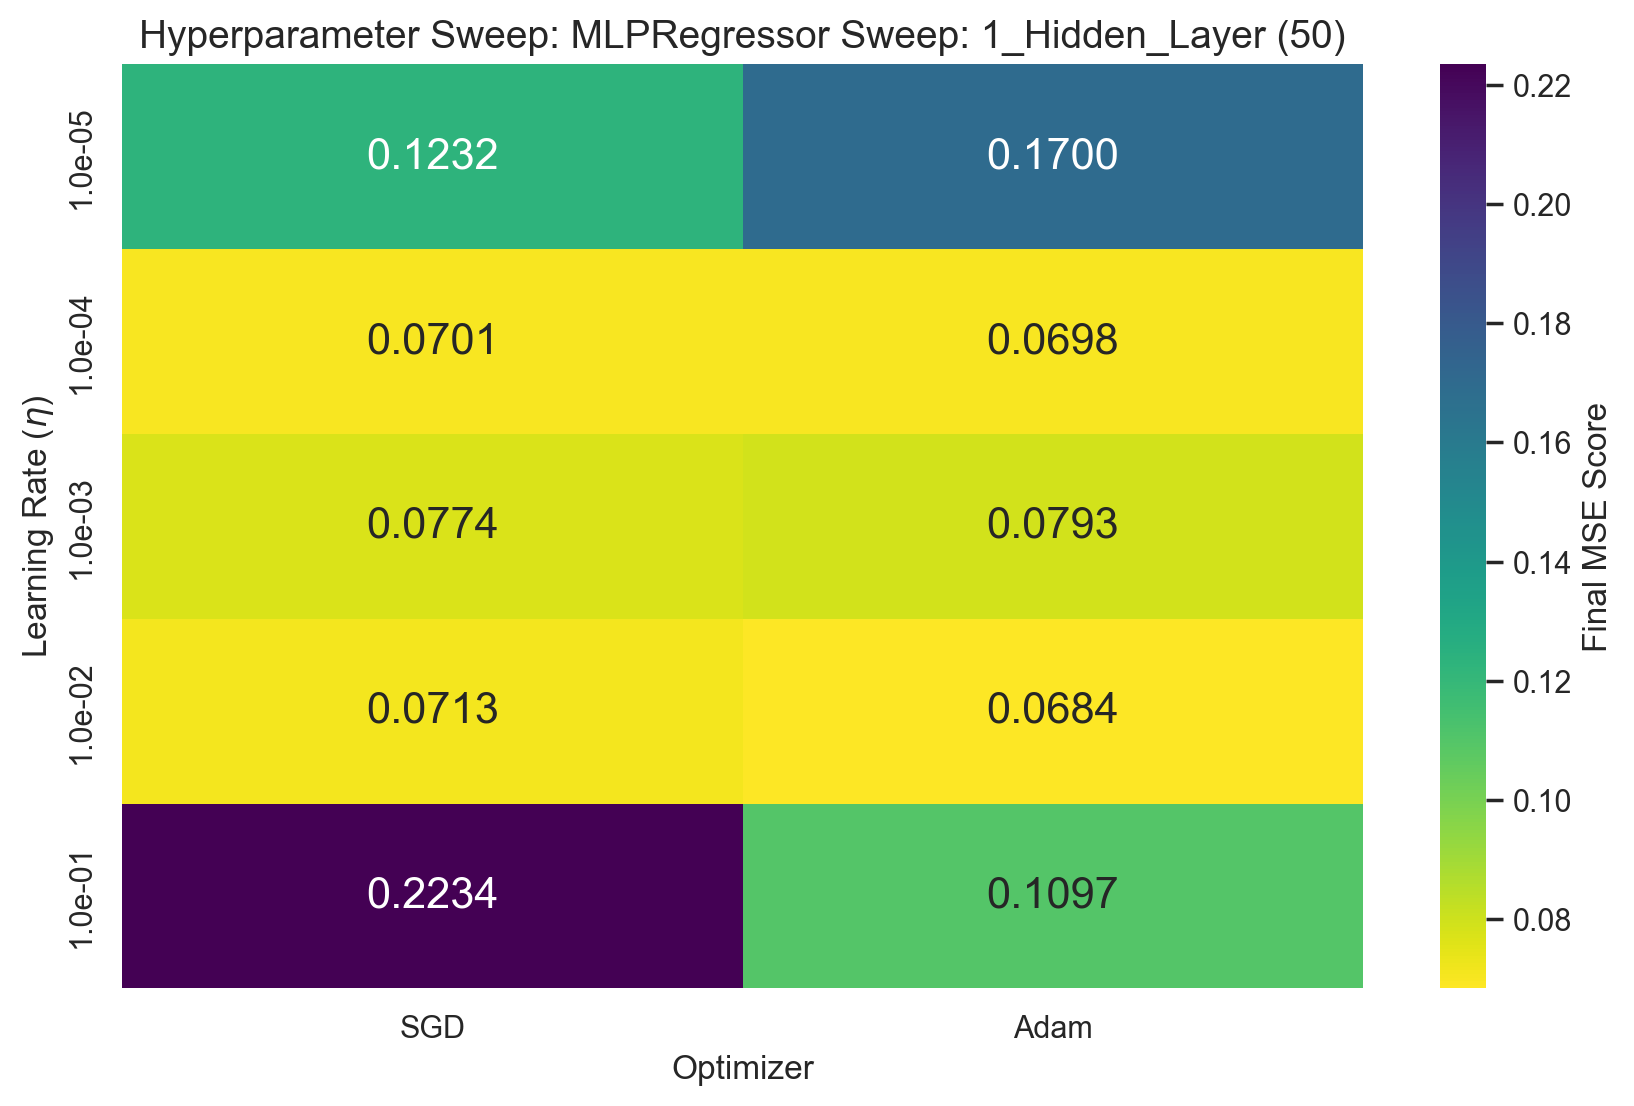

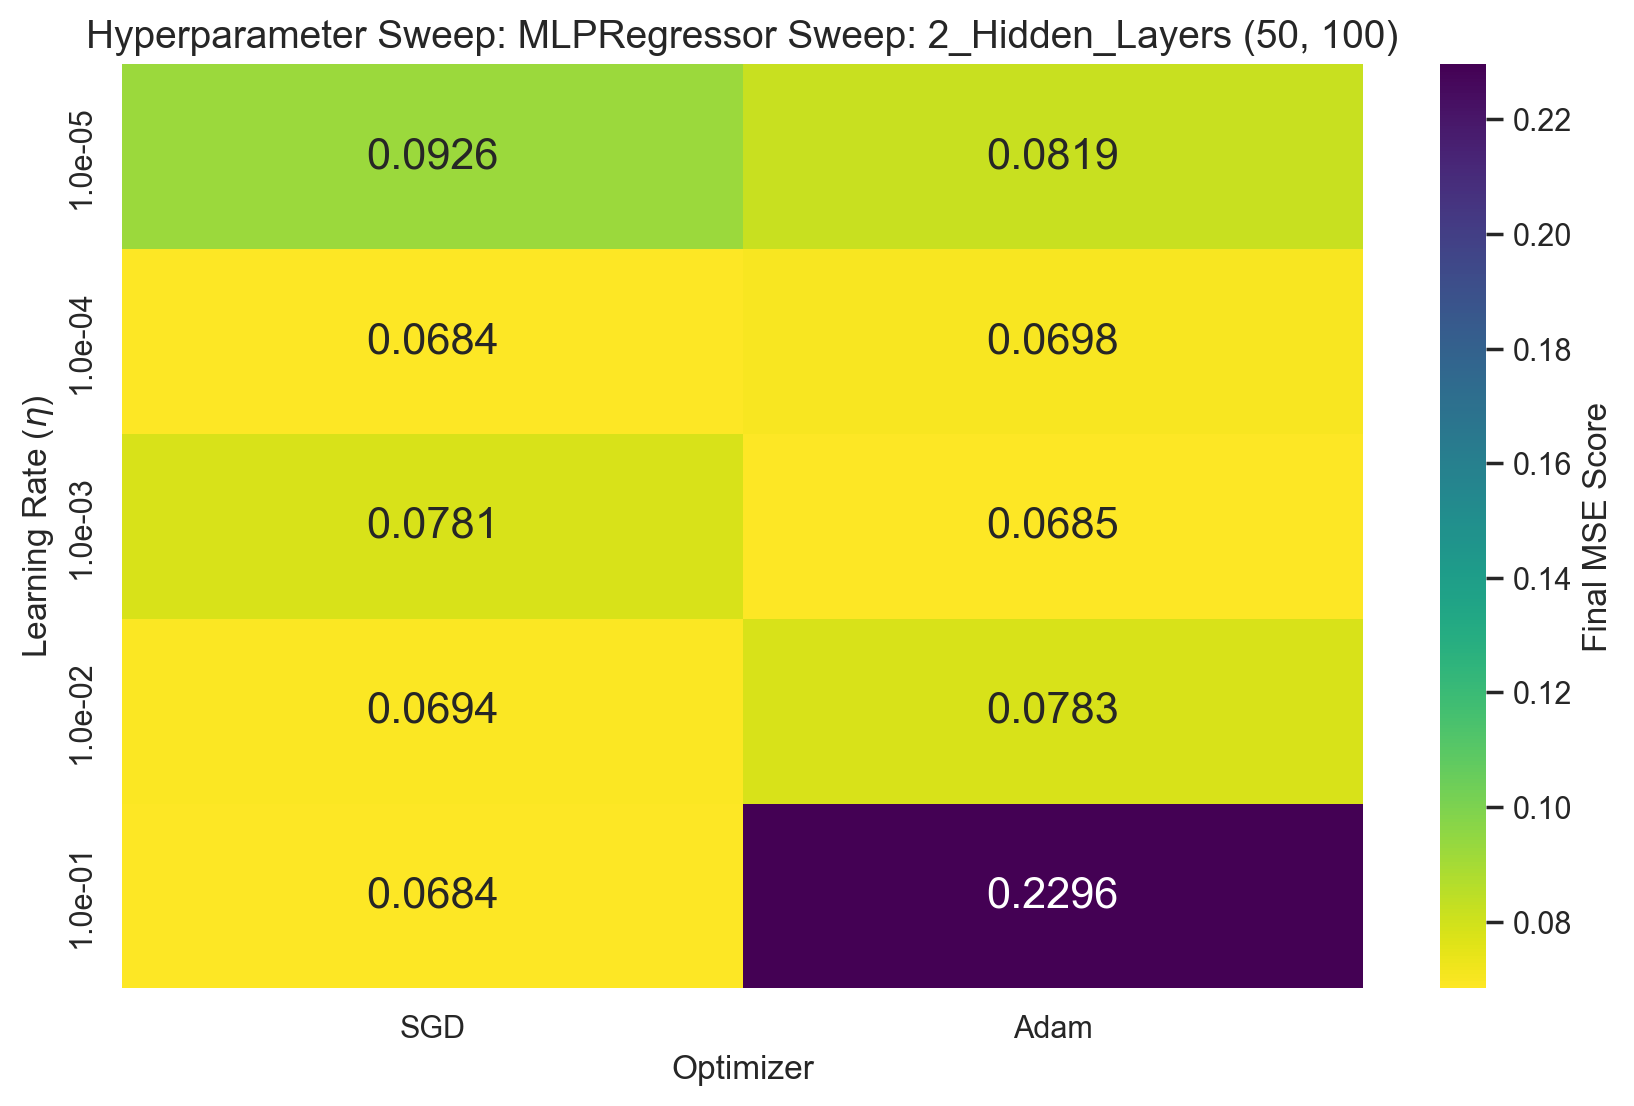

In [ ]:
def plot_sweep_heatmap(sweep_data, eta_vals, title):
    """Heatmap of final MSE scores."""
    # Rows: eta, Columns: Optimizers
    df = pd.DataFrame(sweep_data, index=[f"{e:.1e}" for e in eta_vals]) 
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        df, 
        annot=True, 
        fmt=".4f", 
        cmap="viridis_r", 
        cbar_kws={'label': 'Final MSE Score'}
    ) 
    plt.title(f'Hyperparameter Sweep: {title}')
    plt.ylabel('Learning Rate ($\eta$)')
    plt.xlabel('Optimizer')
    plt.show()

for arch_name, sweep_data in skl_sweep_results.items():
    plot_sweep_heatmap(sweep_data, eta_vals, f"MLPRegressor Sweep: {arch_name}")



### Autograd check

In [ ]:
#Recreate X_batch and t_batch in FFNN from earlier for autograd check
batch_size_test = 25
n_test = X_test_scaled.shape[0] 
batch_size_test = min(batch_size_test, n_test)

# Randomly select start index for mini-batch
start_index = np.random.randint(0, n_test - batch_size_test)
end_index = start_index + batch_size_test

# Create mini-batch
X_batch = X_test_scaled[start_index:end_index]
t_batch = y_test[start_index:end_index]

# Use the previously defined FFNN 
manual_grads = nn.compute_gradient(X_batch, t_batch)

# Compute gradients using autograd
autograd_grads = nn.autograd_gradient(X_batch, t_batch)

# Compare gradients layer by layer
for i in range(len(nn.layers)):
    # Separate Weight gradients (index 0) and Bias gradients (index 1)
    manual_W_g, manual_b_g = manual_grads[i]
    autograd_W_g, autograd_b_g = autograd_grads[i]

    # Compare the arrays individually using np.allclose
    weights_match = np.allclose(manual_W_g, autograd_W_g)
    biases_match = np.allclose(manual_b_g, autograd_b_g)

    print(f"Layer {i}: Weights match: {weights_match}, Biases match: {biases_match}")

print(X_batch.shape, t_batch.shape)
print("any NaN in X?", np.isnan(X_batch).any(), " any NaN in t?", np.isnan(t_batch).any())


Layer 0: Weights match: True, Biases match: True
Layer 1: Weights match: True, Biases match: True
Layer 2: Weights match: True, Biases match: True
(25, 1) (25, 1)
any NaN in X? False  any NaN in t? False


# Part d

In [ ]:
from Code.activations import sigmoid, RELU, LRELU, identity, derivate
from Code.scheduler import Constant, RMS_prop, Adam

input_nodes = X_train_scaled.shape[1] # Features from scaled data
output_nodes = 1
layer_output_sizes_2H = [50, 100, output_nodes]
n_hidden_layers = len(layer_output_sizes_2H) - 1  # Should be 2 hidden layers
eta_constant = 0.01 # Learning rate for optimizers


activation_tests = {
    'Sigmoid': sigmoid,
    'RELU': RELU,
    'LRELU': LRELU
}


rho_val = 0.9
rho2_val = 0.999
batches = 25

optimizers_to_sweep = {
    'Constant': (Constant, {}),
    'RMS_prop': (RMS_prop, {'rho': rho_val}),
    'Adam': (Adam, {'rho': rho_val, 'rho2': rho2_val})
}

architectures_to_sweep = {
    '1_Hidden_Layer (50)': layer_sizes_1H,
    '2_Hidden_Layers (50, 100)': layer_sizes_2H
}



In [ ]:
all_activation_results = {}
all_architectural_results = {}

# Iterate over architectures
for arch_name, layer_output_sizes in architectures_to_sweep.items():
    
    n_hidden_layers = len(layer_output_sizes) - 1
    all_activation_results = {}
    
    print(f"\n================ {arch_name} ================")

    # Iterate through Hidden Activation Functions
    for act_name, h_func in activation_tests.items():
        
        # Construct the complete list of activation functions for this architecture
        activation_funcs = [h_func] * n_hidden_layers + [identity] 
        activation_ders = [derivate(f) for f in activation_funcs]
        
        #Score storage for this activation function
        current_act_scores = {}
        
        # Iterate through Optimizers
        for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
            
            # Prepare kwargs, keeping eta constant
            current_kwargs = {'eta': eta_constant}
            current_kwargs.update(fixed_params)
            
            # Initialize FFNN with this architecture and activation setup
            nn = FFNN(
                network_input_size=input_nodes,
                layer_output_sizes=tuple(layer_output_sizes),
                activation_funcs=activation_funcs,
                activation_ders=activation_ders,
                cost_fun=CostOLS,
                cost_der=dCostOLS,
                seed=42
            )
            nn.reset_weights() 
            
            # Instantiate optimizer
            scheduler_instance = optimizer_class(**current_kwargs)

            # Train 
            scores = nn.fit(
                X_train_scaled, y_train, 
                scheduler=scheduler_instance, 
                batches=batches, 
                epochs=epochs_comparison, 
                lam=lam
            )
            
            # Log results
            final_mse = scores['train_errors'][-1]
            current_act_scores[opt_name] = final_mse
            print(f" {arch_name} | {act_name} + {opt_name}: MSE={final_mse:.6f}")

        all_activation_results[act_name] = current_act_scores

# Store all activation function results for this architecture
    all_architectural_results[arch_name] = all_activation_results
    for i, (W, b) in enumerate(nn.layers):
        print(f"Layer {i}: mean(W)={np.mean(W):.3e}, std(W)={np.std(W):.3e}")


    acts = nn._feed_forward_saver(X_train_scaled)[0]  # first hidden layer activations
    print("Fraction of zeros:", np.mean(acts == 0)) # Check fraction of zeros in activations for first hidden layer because RELU/LRELU




================ 1_Hidden_Layer (50) ================
 1_Hidden_Layer (50) | Sigmoid + Constant: MSE=0.095520
 1_Hidden_Layer (50) | Sigmoid + RMS_prop: MSE=0.086021
 1_Hidden_Layer (50) | Sigmoid + Adam: MSE=0.086423
 1_Hidden_Layer (50) | RELU + Constant: MSE=0.019810
 1_Hidden_Layer (50) | RELU + RMS_prop: MSE=0.000332
 1_Hidden_Layer (50) | RELU + Adam: MSE=0.000244
 1_Hidden_Layer (50) | LRELU + Constant: MSE=0.019810
 1_Hidden_Layer (50) | LRELU + RMS_prop: MSE=0.000808
 1_Hidden_Layer (50) | LRELU + Adam: MSE=0.000252
Layer 0: mean(W)=6.486e-03, std(W)=3.915e-01
Layer 1: mean(W)=1.503e-01, std(W)=3.647e-01
Fraction of zeros: 0.0

================ 2_Hidden_Layers (50, 100) ================
 2_Hidden_Layers (50, 100) | Sigmoid + Constant: MSE=0.100258
 2_Hidden_Layers (50, 100) | Sigmoid + RMS_prop: MSE=0.085974
 2_Hidden_Layers (50, 100) | Sigmoid + Adam: MSE=0.086002
 2_Hidden_Layers (50, 100) | RELU + Constant: MSE=0.000797
 2_Hidden_Layers (50, 100) | RELU + RMS_prop: MSE=0.0

In [ ]:
def plot_activation_sweep_heatmap(results_data, row_labels, title, eta_constant):

    df = pd.DataFrame(results_data).T 
    plt.figure(figsize=(10, 6)) 
    
    sns.heatmap(
        df, 
        annot=True, 
        fmt=".6f",
        cmap="viridis_r",
        cbar_kws={'label': 'Final MSE Score'}
    )
    
    plt.title(f'{title} (Fixed $\eta={eta_constant}$)') 
    plt.ylabel('Hidden Layer Activation Function')
    plt.xlabel('Optimizer')
    plt.show()
    plt.close()

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
/var/folders/yn/p45qg2hs32j6_2k0vv9s4kcw0000gn/T/ipykernel_33267/133446581.py:14: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'{title} (Fixed $\eta={eta_constant}$)')



 Heatmaps for All Architectures


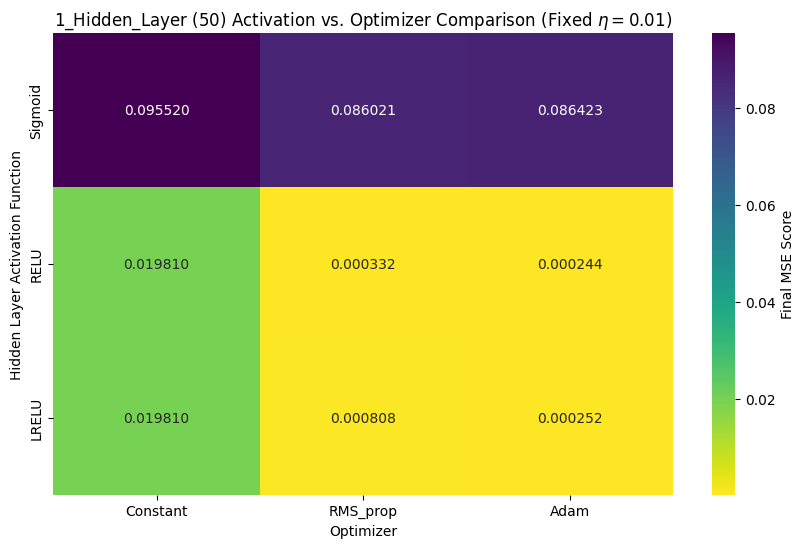

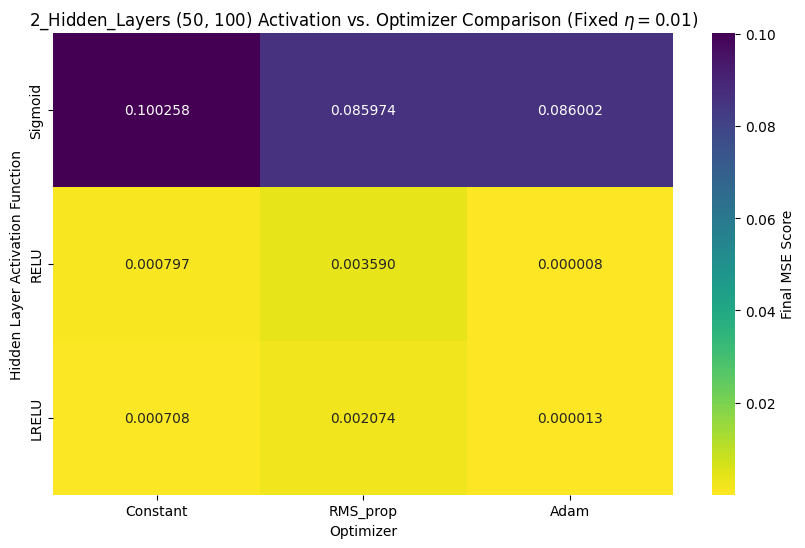

In [ ]:
print("\n Heatmaps for All Architectures")

activation_names = list(activation_tests.keys())

# Iterate over architectures to plot heatmaps
for arch_name, activation_scores in all_architectural_results.items():
    
    # activation_scores holds the data (Activation vs Optimizer MSE grid) for one architecture
    
    plot_activation_sweep_heatmap(
        results_data=activation_scores, 
        row_labels=activation_names, 
        title=f'{arch_name} Activation vs. Optimizer Comparison',
        eta_constant=eta_constant
    )


# Part e

In [ ]:
def build_architectures(depths=(0,1,2,3), widths=(5,10,25,50), out_dim=1):
    """
    Returns a dict mapping a compact name -> layer_output_sizes list.
    Name encodes depth (hidden layers) and width (neurons per hidden layer).
    For depth=0 we produce only the output layer [out_dim].
    """
    arch = {}
    for d in depths:
        for w in widths:
            if d == 0:
                name = f"0L-OUT{out_dim}"
                sizes = [out_dim]
            else:
                name = f"{d}L-{w}N"
                sizes = [w]*d + [out_dim]
            arch[name] = sizes
    return arch

# Example:
architectures_to_sweep = build_architectures(depths=(0,1,2,3), widths=(5,10,25,50), out_dim=1)


## L2 regularization

In [ ]:
lam_vals = np.logspace(-5, 2, 8) 


L2_sweep_results = {}

print("\n\n================ L2 (Ridge) Regularization ================")

#L2 sweep
for arch_name, layer_sizes in architectures_to_sweep.items():
    arch_scores = {}
    print(f"\n---- Sweep for {arch_name} ----")
    # Iterate over optimizers
    for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
        print(f"--- Optimizer {opt_name} ---")
        
        # Store results for this optimizer across all eta and lambda values
        optimizer_results_grid = np.zeros((len(eta_vals), len(lam_vals)))
        # Iterate over eta values
        for i, eta in enumerate(eta_vals):
            for j, lam in enumerate(lam_vals): # New loop for lambda
                
                # Prepare kwargs for the current run
                current_kwargs = {'eta': eta}
                current_kwargs.update(fixed_params)
                
                # Run comparison with L2 regularization (lam parameter)
                scores, nn = run_comparison(
                    optimizer_class, 
                    X_train_scaled, 
                    y_train, 
                    network_input_size=input_nodes, 
                    layer_output_sizes=layer_sizes, 
                    epochs=epochs_sweep, 
                    l2=lam, # Pass regularization parameter
                    **current_kwargs
                )
                
                y_pred_test = nn.predict(X_test_scaled)
                final_mse = CostOLS(y_pred_test, y_test)
                
                optimizer_results_grid[i, j] = final_mse
                print(f"  {opt_name} (eta={eta:.1e}, lam={lam:.1e}): MSE={final_mse:.6f}")
        
        arch_scores[opt_name] = optimizer_results_grid

    L2_sweep_results[arch_name] = arch_scores



================ L2 (Ridge) Regularization ================

---- Sweep for 0L-OUT1 ----
--- Optimizer Constant ---
  Constant (eta=1.0e-05, lam=1.0e-05): MSE=0.105029
  Constant (eta=1.0e-05, lam=1.0e-04): MSE=0.105029
  Constant (eta=1.0e-05, lam=1.0e-03): MSE=0.105029
  Constant (eta=1.0e-05, lam=1.0e-02): MSE=0.105029
  Constant (eta=1.0e-05, lam=1.0e-01): MSE=0.105028
  Constant (eta=1.0e-05, lam=1.0e+00): MSE=0.105018
  Constant (eta=1.0e-05, lam=1.0e+01): MSE=0.104964
  Constant (eta=1.0e-05, lam=1.0e+02): MSE=0.104946
  Constant (eta=1.0e-04, lam=1.0e-05): MSE=0.068399
  Constant (eta=1.0e-04, lam=1.0e-04): MSE=0.068399
  Constant (eta=1.0e-04, lam=1.0e-03): MSE=0.068399
  Constant (eta=1.0e-04, lam=1.0e-02): MSE=0.068398
  Constant (eta=1.0e-04, lam=1.0e-01): MSE=0.068397
  Constant (eta=1.0e-04, lam=1.0e+00): MSE=0.068389
  Constant (eta=1.0e-04, lam=1.0e+01): MSE=0.068369
  Constant (eta=1.0e-04, lam=1.0e+02): MSE=0.068363
  Constant (eta=1.0e-03, lam=1.0e-05): MSE=0.06943

/var/folders/yn/p45qg2hs32j6_2k0vv9s4kcw0000gn/T/ipykernel_33267/2260785107.py:5: RuntimeWarning: overflow encountered in square
  return np.mean((pred - target) ** 2)
/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/Code/ffnn2.py:85: RuntimeWarning: overflow encountered in multiply
  l2_term = sum(np.sum(W*W)       for W, _ in self.layers)
/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/Code/ffnn2.py:133: RuntimeWarning: overflow encountered in multiply
  dW_L += self.l2 * W_L # L2 gradient
/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/Code/ffnn2.py:261: RuntimeWarning: invalid value encountered in subtract
  W -= W_change # Update weights


  Constant (eta=1.0e-01, lam=1.0e+02): MSE=nan
--- Optimizer RMS_prop ---
  RMS_prop (eta=1.0e-05, lam=1.0e-05): MSE=0.092868
  RMS_prop (eta=1.0e-05, lam=1.0e-04): MSE=0.092868
  RMS_prop (eta=1.0e-05, lam=1.0e-03): MSE=0.092868
  RMS_prop (eta=1.0e-05, lam=1.0e-02): MSE=0.092868
  RMS_prop (eta=1.0e-05, lam=1.0e-01): MSE=0.092870
  RMS_prop (eta=1.0e-05, lam=1.0e+00): MSE=0.092883
  RMS_prop (eta=1.0e-05, lam=1.0e+01): MSE=0.092924
  RMS_prop (eta=1.0e-05, lam=1.0e+02): MSE=0.092940
  RMS_prop (eta=1.0e-04, lam=1.0e-05): MSE=0.069114
  RMS_prop (eta=1.0e-04, lam=1.0e-04): MSE=0.069114
  RMS_prop (eta=1.0e-04, lam=1.0e-03): MSE=0.069114
  RMS_prop (eta=1.0e-04, lam=1.0e-02): MSE=0.069114
  RMS_prop (eta=1.0e-04, lam=1.0e-01): MSE=0.069109
  RMS_prop (eta=1.0e-04, lam=1.0e+00): MSE=0.069082
  RMS_prop (eta=1.0e-04, lam=1.0e+01): MSE=0.069037
  RMS_prop (eta=1.0e-04, lam=1.0e+02): MSE=0.069022
  RMS_prop (eta=1.0e-03, lam=1.0e-05): MSE=0.069325
  RMS_prop (eta=1.0e-03, lam=1.0e-04): MSE

/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/.venv/lib/python3.12/site-packages/autograd/tracer.py:48: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)
/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/.venv/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:53: RuntimeWarning: overflow encountered in square
  lambda ans, x, y : unbroadcast_f(y, lambda g: - g * x / y**2))
/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/.venv/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:75: RuntimeWarning: invalid value encountered in multiply
  defvjp(anp.exp,    lambda ans, x : lambda g: ans * g)


  Constant (eta=1.0e-01, lam=1.0e+02): MSE=nan
--- Optimizer RMS_prop ---
  RMS_prop (eta=1.0e-05, lam=1.0e-05): MSE=0.068625
  RMS_prop (eta=1.0e-05, lam=1.0e-04): MSE=0.068625
  RMS_prop (eta=1.0e-05, lam=1.0e-03): MSE=0.068625
  RMS_prop (eta=1.0e-05, lam=1.0e-02): MSE=0.068632
  RMS_prop (eta=1.0e-05, lam=1.0e-01): MSE=0.068716
  RMS_prop (eta=1.0e-05, lam=1.0e+00): MSE=0.070014
  RMS_prop (eta=1.0e-05, lam=1.0e+01): MSE=0.083066
  RMS_prop (eta=1.0e-05, lam=1.0e+02): MSE=0.091633
  RMS_prop (eta=1.0e-04, lam=1.0e-05): MSE=0.069159
  RMS_prop (eta=1.0e-04, lam=1.0e-04): MSE=0.069159
  RMS_prop (eta=1.0e-04, lam=1.0e-03): MSE=0.069152
  RMS_prop (eta=1.0e-04, lam=1.0e-02): MSE=0.069107
  RMS_prop (eta=1.0e-04, lam=1.0e-01): MSE=0.068899
  RMS_prop (eta=1.0e-04, lam=1.0e+00): MSE=0.068599
  RMS_prop (eta=1.0e-04, lam=1.0e+01): MSE=0.068969
  RMS_prop (eta=1.0e-04, lam=1.0e+02): MSE=0.069018
  RMS_prop (eta=1.0e-03, lam=1.0e-05): MSE=0.069285
  RMS_prop (eta=1.0e-03, lam=1.0e-04): MSE

## L1 regularization

In [ ]:
l1_vals = np.logspace(-5, 0, 6)
L1_sweep_results = {}
print("\n\n================  L1 (Lasso) Regularization  ================")
#L1 sweep
for arch_name, layer_sizes in architectures_to_sweep.items():
    arch_scores = {}
    print(f"\n---- Sweep for {arch_name} ----")
    # Iterate over optimizers
    for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
        print(f"--- Optimizer {opt_name} ---")
        optimizer_results_grid = np.zeros((len(eta_vals), len(l1_vals)))
        # Iterate over eta values
        for i, eta in enumerate(eta_vals):
            # Iterate over l1 values
            for j, l1_ in enumerate(l1_vals):
                current_kwargs = {'eta': eta} 
                current_kwargs.update(fixed_params)
                scores, nn = run_comparison(
                    optimizer_class,
                    X_train_scaled, y_train,
                    network_input_size=input_nodes,
                    layer_output_sizes=layer_sizes,
                    epochs=epochs_sweep,
                    l1=l1_,     # <--- NEW: L1 penalty
                    l2=0.0,     # keep L2 off in this sweep
                    **current_kwargs
                )
                y_pred_test = nn.predict(X_test_scaled)
                final_mse = CostOLS(y_pred_test, y_test)
                optimizer_results_grid[i, j] = final_mse # Store in grid
                print(f" {opt_name} (eta={eta:.1e}, l1={l1_:.1e}): MSE={final_mse:.6f}")
        arch_scores[opt_name] = optimizer_results_grid
    L1_sweep_results[arch_name] = arch_scores




================  L1 (Lasso) Regularization  ================

---- Sweep for 0L-OUT1 ----
--- Optimizer Constant ---
 Constant (eta=1.0e-05, l1=1.0e-05): MSE=0.105029
 Constant (eta=1.0e-05, l1=1.0e-04): MSE=0.105028
 Constant (eta=1.0e-05, l1=1.0e-03): MSE=0.105024
 Constant (eta=1.0e-05, l1=1.0e-02): MSE=0.104979
 Constant (eta=1.0e-05, l1=1.0e-01): MSE=0.104949
 Constant (eta=1.0e-05, l1=1.0e+00): MSE=0.104948
 Constant (eta=1.0e-04, l1=1.0e-05): MSE=0.068398
 Constant (eta=1.0e-04, l1=1.0e-04): MSE=0.068398
 Constant (eta=1.0e-04, l1=1.0e-03): MSE=0.068393
 Constant (eta=1.0e-04, l1=1.0e-02): MSE=0.068363
 Constant (eta=1.0e-04, l1=1.0e-01): MSE=0.068362
 Constant (eta=1.0e-04, l1=1.0e+00): MSE=0.068362
 Constant (eta=1.0e-03, l1=1.0e-05): MSE=0.069437
 Constant (eta=1.0e-03, l1=1.0e-04): MSE=0.069436
 Constant (eta=1.0e-03, l1=1.0e-03): MSE=0.069424
 Constant (eta=1.0e-03, l1=1.0e-02): MSE=0.069342
 Constant (eta=1.0e-03, l1=1.0e-01): MSE=0.069326
 Constant (eta=1.0e-03, l1=1.0

In [ ]:
def build_architectures(depths=(0,1,2,3), widths=(5,10,25,50), out_dim=1):
    """
    Returns a dict mapping a compact name -> layer_output_sizes list.
    Name encodes depth (hidden layers) and width (neurons per hidden layer).
    For depth=0 we produce only the output layer [out_dim].
    """
    arch = {}
    for d in depths:
        for w in widths:
            if d == 0:
                name = f"0L-OUT{out_dim}"
                sizes = [out_dim]
            else:
                name = f"{d}L-{w}N"
                sizes = [w]*d + [out_dim]
            arch[name] = sizes
    return arch

# Example:
architectures_to_sweep = build_architectures(depths=(0,1,2,3), widths=(5,10,25,50), out_dim=1)


In [ ]:
import re

_arch_re = re.compile(r"(?P<d>\d+)L-(?P<w>\d+)N")  # matches like "2L-50N"

def _parse_depth_width(arch_name):
    m = _arch_re.search(arch_name)
    if not m:
        # fallback for names like "1_Hidden_Layer (50, 100)" -> try to infer
        # defaults to NaNs if we cannot parse
        return np.nan, np.nan
    return int(m.group("d")), int(m.group("w"))

def summarize_sweep_results(sweep_results, eta_vals, reg_vals, reg_name="lambda", top_k=10):
    """
    Generic summary for both L1 & L2 sweeps.
    sweep_results : dict  {arch_name -> {optimizer -> 2D array (len(eta_vals) x len(reg_vals))}}
    """
    rows = []
    for arch_name, opt_dict in sweep_results.items():
        depth, width = _parse_depth_width(arch_name)
        for opt_name, grid in opt_dict.items():
            i, j = np.unravel_index(np.nanargmin(grid), grid.shape)
            rows.append({
                "architecture": arch_name,
                "depth": depth,
                "width": width,
                "optimizer": opt_name,
                "best_mse": float(grid[i, j]),
                "eta": float(eta_vals[i]),
                reg_name: float(reg_vals[j]),
            })

    df = pd.DataFrame(rows).sort_values("best_mse").reset_index(drop=True)

    best_per_arch = (
        df.loc[df.groupby("architecture")["best_mse"].idxmin()]
          .sort_values("best_mse")
          .reset_index(drop=True)
    )

    # Useful pivot for quick heatmaps: best MSE per (depth, width)
    pivot_best_by_dw = (best_per_arch
                        .pivot_table(index="depth", columns="width", values="best_mse", aggfunc="min"))

    top_overall = df.head(top_k)
    return df, best_per_arch, top_overall, pivot_best_by_dw

def print_summary_table(df, reg_name="lambda"):
    cols = ["architecture","depth","width","optimizer","eta",reg_name,"best_mse"]
    print("| " + " | ".join(cols) + " |")
    print("|" + "|".join(["---"]*len(cols)) + "|")
    for _, r in df[cols].iterrows():
        print(f"| {r['architecture']} | {r['depth']} | {r['width']} | "
              f"{r['optimizer']} | {r['eta']:.1e} | {r[reg_name]:.1e} | {r['best_mse']:.6f} |")


In [ ]:

def summarize_sweep_results(sweep_results, eta_vals, reg_vals, reg_name="lambda", top_k=10):
    """
""" """     Generic function to summarize best NN hyperparameter results for L1/L2 sweeps.

    sweep_results : dict (arch_name -> optimizer -> (eta x reg) grid)
    eta_vals      : list of learning rate values
    reg_vals      : list of regularization values (L1 or L2)
    reg_name      : string ("lambda" for L2, "l1" for L1)
    top_k         : show top K configs overall
    """ """ """

    rows = []
    for arch_name, opt_dict in sweep_results.items():
        for opt_name, grid in opt_dict.items():
            # find index of best (lowest) MSE
            i, j = np.unravel_index(np.nanargmin(grid), grid.shape)
            rows.append({
                "architecture": arch_name,
                "optimizer": opt_name,
                "best_mse": float(grid[i, j]),
                "eta": float(eta_vals[i]),
                reg_name: float(reg_vals[j]),  # dynamically store l1 or lambda
            })

    df = pd.DataFrame(rows).sort_values("best_mse").reset_index(drop=True)

    # Best per architecture
    best_per_arch = (
        df.loc[df.groupby("architecture")["best_mse"].idxmin()]
        .sort_values("best_mse")
        .reset_index(drop=True)
    )

    top_overall = df.head(top_k)

    return df, best_per_arch, top_overall


In [ ]:
def print_summary_table(df, reg_name="lambda"):
    cols = ["architecture","optimizer","eta",reg_name,"best_mse"]
    print("| " + " | ".join(cols) + " |")
    print("|" + "|".join(["---"]*len(cols)) + "|")
    for _, r in df[cols].iterrows():
        print(f"| {r['architecture']} | {r['optimizer']} | {r['eta']:.1e} | {r[reg_name]:.1e} | {r['best_mse']:.6f} |")


In [ ]:
df_l2_all, df_l2_best_arch, df_l2_top = summarize_sweep_results(
    L2_sweep_results, eta_vals, lam_vals, reg_name="lambda"
)

print("\n### Best per architecture (L2)")
print_summary_table(df_l2_best_arch, reg_name="lambda")



### Best per architecture (L2)
| architecture | optimizer | eta | lambda | best_mse |
|---|---|---|---|---|
| 2L-5N | Adam | 1.0e-02 | 1.0e-05 | 0.000257 |
| 3L-10N | Adam | 1.0e-02 | 1.0e-05 | 0.000467 |
| 2L-50N | Adam | 1.0e-01 | 1.0e-05 | 0.000572 |
| 2L-10N | Adam | 1.0e-02 | 1.0e-05 | 0.000641 |
| 1L-25N | Adam | 1.0e-01 | 1.0e-05 | 0.000709 |
| 1L-10N | Adam | 1.0e-01 | 1.0e-05 | 0.000849 |
| 1L-5N | Adam | 1.0e-01 | 1.0e-05 | 0.001302 |
| 2L-25N | Adam | 1.0e-01 | 1.0e-05 | 0.001917 |
| 3L-50N | Adam | 1.0e-01 | 1.0e-05 | 0.003570 |
| 3L-5N | Adam | 1.0e-02 | 1.0e-05 | 0.006832 |
| 3L-25N | Constant | 1.0e-02 | 1.0e-02 | 0.068338 |
| 1L-50N | Constant | 1.0e-01 | 1.0e+01 | 0.068341 |
| 0L-OUT1 | Constant | 1.0e-04 | 1.0e+02 | 0.068363 |


In [ ]:
df_l2_all, df_l2_best_arch, df_l2_top, l2_best_pivot = summarize_sweep_results(
    L2_sweep_results, eta_vals, lam_vals, reg_name="lambda"
)
print("\n### Best per architecture (L2)")
print_summary_table(df_l2_best_arch, reg_name="lambda")


### Best per architecture (L2)
| architecture | optimizer | eta | lambda | best_mse |
|---|---|---|---|---|
| 2L-5N | Adam | 1.0e-02 | 1.0e-05 | 0.000257 |
| 3L-10N | Adam | 1.0e-02 | 1.0e-05 | 0.000467 |
| 2L-50N | Adam | 1.0e-01 | 1.0e-05 | 0.000572 |
| 2L-10N | Adam | 1.0e-02 | 1.0e-05 | 0.000641 |
| 1L-25N | Adam | 1.0e-01 | 1.0e-05 | 0.000709 |
| 1L-10N | Adam | 1.0e-01 | 1.0e-05 | 0.000849 |
| 1L-5N | Adam | 1.0e-01 | 1.0e-05 | 0.001302 |
| 2L-25N | Adam | 1.0e-01 | 1.0e-05 | 0.001917 |
| 3L-50N | Adam | 1.0e-01 | 1.0e-05 | 0.003570 |
| 3L-5N | Adam | 1.0e-02 | 1.0e-05 | 0.006832 |
| 3L-25N | Constant | 1.0e-02 | 1.0e-02 | 0.068338 |
| 1L-50N | Constant | 1.0e-01 | 1.0e+01 | 0.068341 |
| 0L-OUT1 | Constant | 1.0e-04 | 1.0e+02 | 0.068363 |


In [ ]:
df_l1_all, df_l1_best_arch, df_l1_top = summarize_sweep_results(
    L1_sweep_results, eta_vals, l1_vals, reg_name="l1"
)

print("\n### Best per architecture (L1)")
print_summary_table(df_l1_best_arch, reg_name="l1")

df_l1_all, df_l1_best_arch, df_l1_top, l1_best_pivot = summarize_sweep_results(
    L1_sweep_results, eta_vals, lam_vals, reg_name="lambda"
)
print("\n### Best per architecture (L1)")
print_summary_table(df_l1_best_arch, reg_name="lambda")


### Best per architecture (L1)
| architecture | optimizer | eta | l1 | best_mse |
|---|---|---|---|---|
| 1L-10N | Adam | 1.0e-01 | 1.0e-05 | 0.000091 |
| 2L-5N | Adam | 1.0e-01 | 1.0e-04 | 0.000326 |
| 2L-50N | Adam | 1.0e-01 | 1.0e-05 | 0.000577 |
| 1L-5N | Adam | 1.0e-01 | 1.0e-05 | 0.000934 |
| 2L-10N | Adam | 1.0e-02 | 1.0e-05 | 0.001241 |
| 2L-25N | RMS_prop | 1.0e-01 | 1.0e-05 | 0.001782 |
| 3L-25N | Constant | 1.0e-02 | 1.0e-04 | 0.068338 |
| 3L-10N | Adam | 1.0e-01 | 1.0e-02 | 0.068339 |
| 3L-50N | RMS_prop | 1.0e-02 | 1.0e-01 | 0.068340 |
| 3L-5N | Constant | 1.0e-01 | 1.0e-03 | 0.068344 |
| 1L-50N | Constant | 1.0e-04 | 1.0e+00 | 0.068354 |
| 1L-25N | RMS_prop | 1.0e-01 | 1.0e-01 | 0.068357 |
| 0L-OUT1 | Constant | 1.0e-04 | 1.0e+00 | 0.068362 |


ValueError: not enough values to unpack (expected 4, got 3)

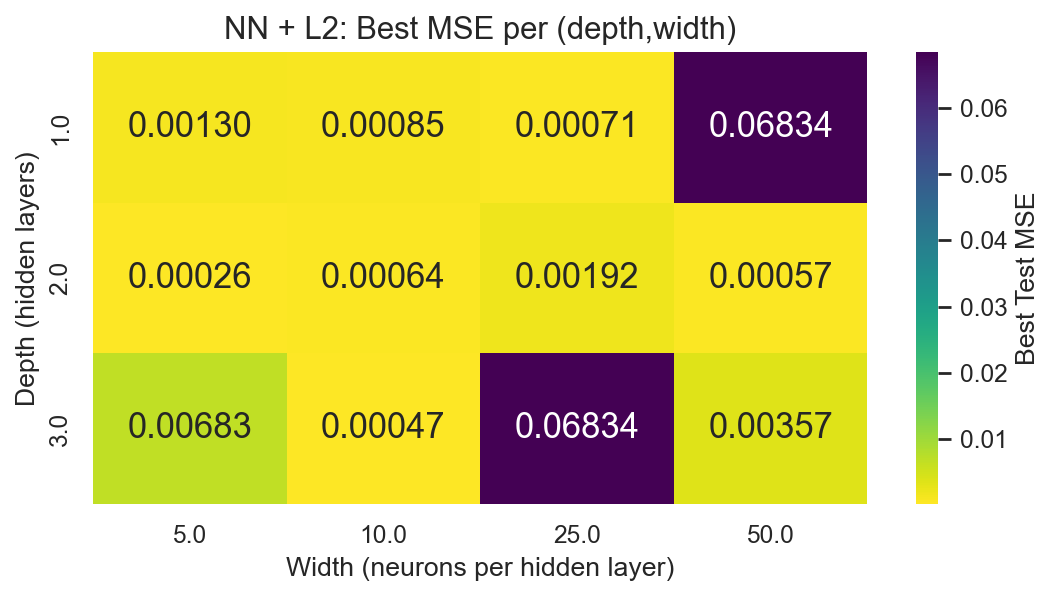

NameError: name 'l1_best_pivot' is not defined

In [ ]:

def plot_best_by_depth_width(pivot, title):
    plt.figure(figsize=(7,4), dpi=160)
    sns.heatmap(pivot, annot=True, fmt=".5f", cmap="viridis_r",
                cbar_kws={"label":"Best Test MSE"})
    plt.title(title)
    plt.ylabel("Depth (hidden layers)")
    plt.xlabel("Width (neurons per hidden layer)")
    plt.tight_layout()
    plt.show()

plot_best_by_depth_width(l2_best_pivot, "NN + L2: Best MSE per (depth,width)")
plot_best_by_depth_width(l1_best_pivot, "NN + L1: Best MSE per (depth,width)")


In [ ]:
import numpy as np

def pick_global_best(results, eta_vals, reg_vals=None):
    """
    results[arch][optimizer] = 
        - array of shape (len(eta_vals), len(reg_vals))  if reg_vals is not None
        - array of shape (len(eta_vals),)               otherwise

    Returns a dict with the best config + value.
    """
    best = {
        "arch": None, "optimizer": None,
        "eta": None, "reg": None,
        "eta_idx": None, "reg_idx": None,
        "mse": np.inf
    }

    for arch_name, arch_scores in results.items():
        for opt_name, grid in arch_scores.items():
            grid = np.asarray(grid)

            if reg_vals is not None:                # 2D grid: (eta, reg)
                i, j = np.unravel_index(np.argmin(grid), grid.shape)
                mse = grid[i, j]
                eta = eta_vals[i]
                reg = reg_vals[j]
                if mse < best["mse"]:
                    best.update(dict(
                        arch=arch_name, optimizer=opt_name,
                        eta=eta, reg=reg, eta_idx=i, reg_idx=j, mse=mse
                    ))
            else:                                    # 1D grid: (eta,)
                i = int(np.argmin(grid))
                mse = grid[i]
                eta = eta_vals[i]
                if mse < best["mse"]:
                    best.update(dict(
                        arch=arch_name, optimizer=opt_name,
                        eta=eta, reg=None, eta_idx=i, reg_idx=None, mse=mse
                    ))
    return best

def pretty_print_best(tag, best, reg_name="lambda"):
    if best["reg"] is None:
        print(f"[{tag}] Best MSE={best['mse']:.6g} with "
              f"arch='{best['arch']}', opt={best['optimizer']}, eta={best['eta']:.1e}")
    else:
        print(f"[{tag}] Best MSE={best['mse']:.6g} with "
              f"arch='{best['arch']}', opt={best['optimizer']}, "
              f"eta={best['eta']:.1e}, {reg_name}={best['reg']:.1e}")


In [ ]:
# L2 (Ridge)
best_l2 = pick_global_best(L2_sweep_results, eta_vals, reg_vals=lam_vals)
pretty_print_best("L2", best_l2, reg_name="lambda")

# L1 (Lasso)
best_l1 = pick_global_best(L1_sweep_results, eta_vals, reg_vals=l1_vals)
pretty_print_best("L1", best_l1, reg_name="l1")

# If you also have a sweep without a reg axis (just eta):
# best_plain = pick_global_best(no_reg_results, eta_vals, reg_vals=None)
# pretty_print_best("NoReg", best_plain)


[L2] Best MSE=0.000257094 with arch='2L-5N', opt=Adam, eta=1.0e-02, lambda=1.0e-05
[L1] Best MSE=9.07673e-05 with arch='1L-10N', opt=Adam, eta=1.0e-01, l1=1.0e-05
